# Gap volatility: how big must the reserve be?

This notebook answers Research Question 1 of the Yagnum paper: **what is the empirically right value of sigma_gap times z_alpha?** It also answers the question that ADR-017 added: **which Monday moment is the settlement moment?**

The paper sizes the Execution Reconciliation Reserve (ERR) with one formula:

$$\text{ERR}_{\text{initial}} = Q \cdot P_{\text{open}} \cdot \sigma_{\text{gap}} \cdot z_{\alpha} + \text{Fees}_{\text{est}}$$

Here Q is the quantity of shares, P_open is the price at which the weekend trade opened, sigma_gap is the typical size of the weekend gap, and z_alpha is a safety multiplier. The worked example in the paper uses sigma_gap = 2% and z = 2.326. Both numbers are placeholders. This notebook replaces them with measured numbers.

## How to read this notebook

Each section teaches the statistical term it needs the first time the term appears. Every code cell has a comment that says what it does. The data lives in a Postgres database that the Yagnum sampler and backfill scripts filled. Nothing in this notebook writes to the database.

The sections are:

0. Setup and data inventory
1. The market gap, two years of real shares
2. The token gap, about 25 weekends of xStock tokens (this section answers ADR-017)
3. Tracking in hours, how well the token follows the share when both trade
4. The ERR back-test
5. Conclusions

## 0. Setup and data inventory

The connection string comes from the `.env` file at the repository root. The notebook never prints it. All price columns in the database are `NUMERIC` (exact decimals). The notebook converts them to floating-point numbers only for statistics and charts. Floating-point is fine for a statistic; it is not fine for money that goes back into a ledger, and nothing here goes back.

In [1]:
# Standard tools. pandas holds tables, numpy does arithmetic, scipy gives the
# statistics, matplotlib draws the charts, zoneinfo converts UTC to New York time.
import re, time, datetime as dt
from pathlib import Path
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

T0 = time.time()
ET = ZoneInfo("America/New_York")
ROOT = Path.cwd().resolve()
while not (ROOT / ".env").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Read DATABASE_URL from .env, strip quotes, switch to the psycopg driver. Never print it.
env_text = (ROOT / ".env").read_text()
url = re.search(r'^DATABASE_URL\s*=\s*(.+)$', env_text, re.M).group(1).strip().strip("'\"")
url = url.replace("postgresql://", "postgresql+psycopg://", 1)
engine = create_engine(url)

def q(sql: str, **params) -> pd.DataFrame:
    """Run one read-only query and return a DataFrame."""
    return pd.read_sql(text(sql), engine, params=params)

# Chart style: the dataviz palette (light surface), thin marks, recessive grid.
C = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100",
         red="#e34948", violet="#4a3aa7", ink="#0b0b0b", ink2="#52514e", grid="#e6e5e1")
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 100, "savefig.dpi": 150,
    "axes.facecolor": "#fcfcfb", "figure.facecolor": "#fcfcfb",
    "axes.edgecolor": C["grid"], "axes.grid": True, "grid.color": C["grid"],
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.frameon": False,
    "text.color": C["ink"], "axes.labelcolor": C["ink2"],
    "xtick.color": C["ink2"], "ytick.color": C["ink2"], "font.size": 10,
})

def save(fig, name: str):
    """Save a figure under notebooks/figures/ and show it inline."""
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    plt.show()

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("connected; figures go to", FIG.relative_to(ROOT))

connected; figures go to notebooks\figures


### What the three tables hold

- `token_candles`: hourly and daily price candles for each xStock token, from GeckoTerminal. A **candle** is one row per time bucket with the open, high, low and close price. GeckoTerminal keeps only the last **180 days** for free, so token history starts around 2026-03-01. A pool prints a candle only in an hour when at least one trade happened, so thin tokens have gaps.
- `market_bars`: Alpaca bars for the real shares. Daily bars go back **two years** (2024-08-01). Minute bars exist only for Monday mornings, 04:00 to 10:30 ET, from 2026-03-02 to 2026-08-24.
- `token_prices`: the live sampler. Every five minutes it stores each token's Jupiter price beside the real share's last trade. It started today (2026-08-28), so it holds only a few hours. It grows from here.

The two histories have different lengths on purpose. Two years of daily bars tell us what real weekend gaps look like with a large sample. 180 days of token candles tell us how the token itself behaves, with a small sample. Section 5 puts the two side by side.

In [2]:
inv_tok = q("""
    select symbol, timeframe, count(*) as candles,
           min(bucket_start) as first_candle, max(bucket_start) as last_candle
    from token_candles group by 1, 2 order by 2, 1""")
inv_mkt = q("""
    select symbol, timeframe, count(*) as bars,
           min(bucket_start) as first_bar, max(bucket_start) as last_bar
    from market_bars group by 1, 2 order by 2, 1""")
inv_live = q("select count(*) as rows, min(sampled_at) as first, max(sampled_at) as last from token_prices")

print("token_candles rows:", inv_tok.candles.sum(), "| market_bars rows:", inv_mkt.bars.sum(),
      "| token_prices rows:", int(inv_live.loc[0, "rows"]))
print("live sampler window:", inv_live.loc[0, "first"], "->", inv_live.loc[0, "last"])

token_candles rows: 57861 | market_bars rows: 38820 | token_prices rows: 160
live sampler window: 2026-08-28 17:08:51.971342+00:00 -> 2026-08-28 18:00:10.920506+00:00


In [3]:
# Candles per token. A dense token has about 24 candles a day; 180 days is about 4,300.
hourly = inv_tok[inv_tok.timeframe == "hour"].set_index("symbol")
hourly["days_covered"] = (hourly.last_candle - hourly.first_candle).dt.days
hourly["fill_rate"] = hourly.candles / (hourly.days_covered * 24)
hourly[["candles", "first_candle", "last_candle", "days_covered", "fill_rate"]]

,candles,first_candle,last_candle,days_covered,fill_rate
symbol,,,,,
AAPLx,4072,2026-03-01 18:00:00+00:00,2026-08-28 17:00:00+00:00,179,0.9479
AMZNx,3428,2026-03-01 18:00:00+00:00,2026-08-28 17:00:00+00:00,179,0.7980
AVGOx,1574,2026-03-02 20:00:00+00:00,2026-08-28 17:00:00+00:00,178,0.3684
COINx,800,2026-07-03 01:00:00+00:00,2026-08-28 17:00:00+00:00,56,0.5952
CRCLx,4062,2026-03-01 18:00:00+00:00,2026-08-28 17:00:00+00:00,179,0.9455
GLDx,4259,2026-03-01 18:00:00+00:00,2026-08-28 17:00:00+00:00,179,0.9914
GOOGLx,3708,2026-03-01 18:00:00+00:00,2026-08-28 17:00:00+00:00,179,0.8631
HOODx,725,2026-07-03 01:00:00+00:00,2026-08-28 17:00:00+00:00,56,0.5394
INTCx,829,2026-07-03 01:00:00+00:00,2026-08-28 17:00:00+00:00,56,0.6168


The `fill_rate` column is the share of hours that have a candle. A token near 1.0 trades almost every hour. A token far below 1.0 has hours with no trade, so its reference price on a Sunday night may be several hours old. Section 2 records that staleness and excludes cases where it is too large.

In [4]:
mkt = inv_mkt.set_index(["timeframe", "symbol"])
print("1Day bars per share (2 years):")
print(mkt.loc["1Day", "bars"].to_string())
mondays = q("""
    select distinct date(bucket_start at time zone 'America/New_York') as monday
    from market_bars where timeframe = '1Min' order by 1""")
print(f"\nMondays with minute bars: {len(mondays)} ({mondays.monday.min()} -> {mondays.monday.max()})")
print("Missing Monday (holiday): 2026-05-25, Memorial Day")

1Day bars per share (2 years):
symbol
AAPL     521
AMZN     521
AVGO     521
COIN     521
CRCL     310
GLD      521
GOOGL    521
HOOD     521
INTC     521
MCD      521
META     521
MSFT     521
MSTR     521
NVDA     521
PLTR     521
QQQ      521
SPY      521
STRC     272
TSLA     521

Mondays with minute bars: 25 (2026-03-02 -> 2026-08-24)
Missing Monday (holiday): 2026-05-25, Memorial Day


## 1. The market gap: two years of real shares

### Terms

- **Log return.** The size of a price move, written as r = ln(P_after / P_before). For small moves it is almost the same as the percent change (a log return of 0.02 is about a 2% move). Log returns add up cleanly and treat a rise and a fall of the same size symmetrically, which is why statisticians prefer them.
- **Standard deviation (sigma).** The typical distance of an observation from the average. If weekend gaps have sigma = 2%, then a "normal" weekend moves the price by about 2% in one direction or the other.
- **Percentile.** The value below which a given share of the observations fall. The 1st percentile is the value that only 1% of the weekends fall below. The 99th percentile is the value that only 1% exceed.
- **The normal distribution (bell curve).** The textbook shape that the paper's z-score assumes. On a bell curve, 99% of outcomes sit above mean - 2.326 sigma, so a seller who reserves 2.326 sigma is covered 99 weekends out of 100.
- **Fat tails.** A distribution has fat tails when extreme values happen more often than the bell curve predicts. Earnings and weekend news make stock gaps fat-tailed.
- **Excess kurtosis.** A number that measures how fat the tails are. The bell curve has excess kurtosis 0. Positive values mean fatter tails; a value of 3 or more means the tails are much fatter than normal.

### Method

For each real share, take every Friday close and the open of the next trading day. On a normal week that is Monday. When Monday is a holiday, the next trading day is Tuesday; those long weekends are **kept** and flagged, because a weekend trader faces them too. The gap is r = ln(open_next / close_Fri).

In [5]:
daily = q("""
    select symbol, bucket_start, open, close from market_bars
    where timeframe = '1Day' order by symbol, bucket_start""")
daily["date"] = daily.bucket_start.dt.tz_convert(ET).dt.date
daily["open"] = daily.open.astype(float)
daily["close"] = daily.close.astype(float)

rows = []
for sym, g in daily.groupby("symbol"):
    g = g.sort_values("date").reset_index(drop=True)
    for i in range(len(g) - 1):
        d0, d1 = g.date[i], g.date[i + 1]
        if d0.weekday() != 4:          # 4 = Friday
            continue
        rows.append(dict(symbol=sym, friday=d0, next_day=d1,
                         long_weekend=d1.weekday() != 0,
                         r=np.log(g.open[i + 1] / g.close[i])))
mkt_gap = pd.DataFrame(rows)
print(f"{len(mkt_gap)} weekend gaps across {mkt_gap.symbol.nunique()} shares; "
      f"{int(mkt_gap.long_weekend.sum())} of them are long weekends")

1864 weekend gaps across 19 shares; 144 of them are long weekends


In [6]:
def describe_gaps(s: pd.Series) -> pd.Series:
    """Per-ticker summary of a gap series (values in log-return units)."""
    s = s.dropna()
    return pd.Series({
        "n": len(s), "mean": s.mean(), "sigma": s.std(ddof=1),
        "p1": s.quantile(0.01), "p5": s.quantile(0.05),
        "p95": s.quantile(0.95), "p99": s.quantile(0.99),
        "excess_kurtosis": stats.kurtosis(s, fisher=True, bias=False) if len(s) > 3 else np.nan,
    })

mkt_stats = mkt_gap.groupby("symbol").r.apply(describe_gaps).unstack()
mkt_stats["n"] = mkt_stats.n.astype(int)
pooled_sigma_mkt = mkt_gap.r.std(ddof=1)
print(f"Pooled market-gap sigma (all shares, all weekends): {pooled_sigma_mkt:.4%}")
print(f"Pooled excess kurtosis: {stats.kurtosis(mkt_gap.r, bias=False):.2f}  (0 = bell curve)")
mkt_stats.sort_values("sigma")

Pooled market-gap sigma (all shares, all weekends): 2.5068%
Pooled excess kurtosis: 26.95  (0 = bell curve)


,n,mean,sigma,p1,p5,p95,p99,excess_kurtosis
symbol,,,,,,,,
MCD,103,-0.0002,0.0071,-0.0152,-0.0092,0.0120,0.0220,2.3953
SPY,103,0.0004,0.0090,-0.0335,-0.0140,0.0116,0.0186,6.2352
MSFT,103,-0.0004,0.0112,-0.0454,-0.0174,0.0149,0.0248,5.3831
QQQ,103,0.0006,0.0119,-0.0370,-0.0168,0.0149,0.0229,5.7219
STRC,53,0.0038,0.0126,-0.0051,-0.0040,0.0140,0.0520,37.3777
GLD,103,0.0015,0.0128,-0.0282,-0.0218,0.0201,0.0330,0.5624
GOOGL,103,0.0012,0.0152,-0.0393,-0.0268,0.0207,0.0338,4.7707
META,103,0.0008,0.0161,-0.0416,-0.0217,0.0224,0.0298,6.7379
AAPL,103,-0.0007,0.0170,-0.0605,-0.0208,0.0159,0.0603,14.3138


Every ticker has positive excess kurtosis. SPY and QQQ, the index funds, have the smallest sigma. Single names are wider, and the crypto-linked names (MSTR, COIN, STRC) are the widest. The sigma of 2% in the paper's example sits in the middle of this range, which is a reasonable place for a placeholder but wrong for most tickers individually.

### The pooled distribution

The chart below stacks all weekend gaps from all shares into one histogram. To compare tickers of different volatility fairly, each gap is first divided by its own ticker's sigma. The result is a **z-score**: a gap of z = 2 means "two sigmas". The dashed curve is the bell curve with the same mean and sigma. If the bars poke above the curve far out on the left and right, the tails are fat.

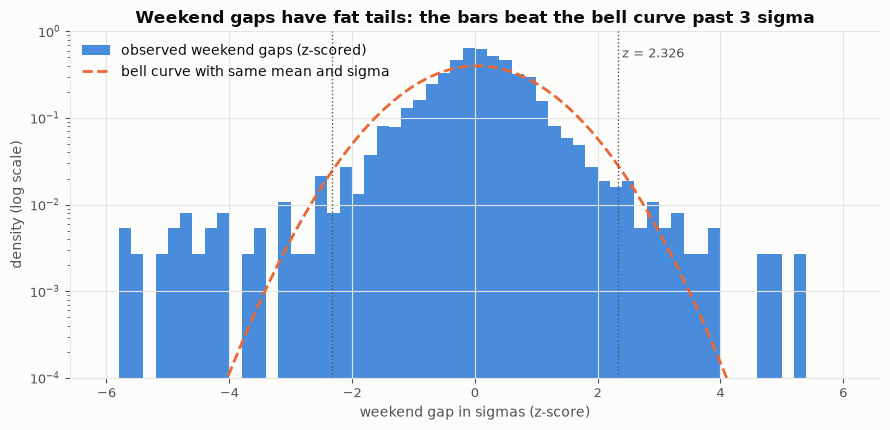

In [7]:
mkt_gap["z"] = mkt_gap.r / mkt_gap.symbol.map(mkt_stats.sigma)
z = mkt_gap.z.values

fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.linspace(-6, 6, 61)
ax.hist(z, bins=bins, density=True, color=C["blue"], alpha=0.85, label="observed weekend gaps (z-scored)")
xs = np.linspace(-6, 6, 400)
ax.plot(xs, stats.norm.pdf(xs, z.mean(), z.std()), color=C["orange"], lw=2, ls="--", label="bell curve with same mean and sigma")
for x in (-2.326, 2.326):
    ax.axvline(x, color=C["ink2"], lw=1, ls=":")
ax.set_yscale("log"); ax.set_ylim(1e-4, 1)
ax.text(2.4, 0.5, "z = 2.326", color=C["ink2"], fontsize=9)
ax.set_xlabel("weekend gap in sigmas (z-score)"); ax.set_ylabel("density (log scale)")
ax.set_title("Weekend gaps have fat tails: the bars beat the bell curve past 3 sigma")
ax.legend(loc="upper left")
save(fig, "01_market_gap_histogram")

The vertical axis is a log scale so the tails are visible. Beyond 3 sigma, the observed bars sit well above the dashed curve: the bell curve says a 4-sigma weekend should happen about 3 times in 100,000; the data has several of them in about 1,800 weekends.

### Coverage test

The paper's z = 2.326 promises that a one-sided reserve is breached only 1% of the time. Here is the actual count. A **seller** is hurt when the market opens lower (r < -z sigma). A **buyer** is hurt when it opens higher (r > +z sigma).

In [8]:
Z_NORMAL = stats.norm.ppf(0.99)   # 2.326: the one-sided 99% point of the bell curve

def coverage(df: pd.DataFrame, zmult: float) -> pd.Series:
    """Fraction of weekends whose gap breached +/- zmult * sigma (per-ticker sigma)."""
    return pd.Series({
        "seller breach rate (r < -z sigma)": (df.z < -zmult).mean(),
        "buyer breach rate  (r > +z sigma)": (df.z > zmult).mean(),
        "weekends": len(df),
    })

cov = coverage(mkt_gap, Z_NORMAL)
print("Target from the bell curve: 1.00% each side\n")
print(f"Seller breach rate: {cov.iloc[0]:.2%}")
print(f"Buyer breach rate:  {cov.iloc[1]:.2%}")
emp_z99 = np.quantile(np.abs(z), 0.99)
print(f"\nEmpirical 99th percentile of |z|: {emp_z99:.2f}  (the bell curve says 2.58 for |z|)")
print(f"Multiplier that gives a true 1% one-sided breach: seller {np.quantile(-z, 0.99):.2f}, buyer {np.quantile(z, 0.99):.2f}")

Target from the bell curve: 1.00% each side

Seller breach rate: 1.93%
Buyer breach rate:  1.50%

Empirical 99th percentile of |z|: 4.10  (the bell curve says 2.58 for |z|)
Multiplier that gives a true 1% one-sided breach: seller 3.50, buyer 2.61


The breach rates are above the 1% the bell curve promises, and the sell side is worse than the buy side because crashes are sharper than rallies. To get a true 1% breach, the multiplier must be between 2.6 (buyer) and 3.5 (seller), not 2.326. This is the fat-tail correction the paper suspected in section 7.

## 2. The token gap: about 25 weekends

This section measures the number the ERR formula actually needs: the move from the **weekend token price** to the **Monday market price**. It also answers ADR-017: which Monday moment should be the settlement moment?

### Definitions

- **P_JUP, the weekend reference price.** The close of the last hourly token candle at or before the reference moment. Two reference moments are measured: **Sunday 23:00 ET** (the last quiet moment before Asian markets and the U.S. premarket wake up) and **Saturday 12:00 ET** (mid-weekend).
- **Staleness rule.** A candle exists only for hours with a trade. The notebook records how many hours old the reference candle is and **excludes a weekend when the candle is more than N = 6 hours stale**. Six hours is one quarter of a day; older than that, the "weekend price" is really a Saturday price.
- **P_MKT, the Monday market price.** The open of the one-minute bar at each candidate moment: 04:00 ET (the first moment Alpaca accepts orders), 07:00, 08:00, 09:00, 09:30 (the opening auction), 09:35 and 10:00. If no bar starts exactly at the moment, the notebook takes the first bar that starts within the next 5 minutes; if there is none, that moment is missing for that weekend. `trade_count` is kept for each bar so thinness is visible.
- **gap = ln(P_MKT / P_JUP).** A positive gap means the market opened above the weekend token price.

**A data limit stated up front.** The minute bars come from Alpaca's free IEX feed. IEX sees almost no trades before 08:00 ET, so 04:00 and 07:00 have no bars in this dataset, and 08:00 has only a handful of trades. This notebook can therefore rank 08:00, 09:00, 09:30, 09:35 and 10:00. The earliest premarket hours need a consolidated feed (SIP) or the sampler's own record, which starts this weekend.

In [9]:
TOKENS = sorted(hourly.index)
SHARE_OF = {t: t[:-1] for t in TOKENS if t != "SPCXx"}   # SPCXx has no listed share

# Hourly token candles. Only the close and the start time are needed.
cand = q("""select symbol, bucket_start, close from token_candles
            where timeframe = 'hour' order by symbol, bucket_start""")
cand["close"] = cand.close.astype(float)
cand_by_sym = {s: g.set_index("bucket_start").close for s, g in cand.groupby("symbol")}

def ref_price(sym: str, moment_utc: pd.Timestamp):
    """Close of the last hourly candle at or before `moment_utc`, plus its age in hours."""
    s = cand_by_sym.get(sym)
    if s is None:
        return np.nan, np.nan
    idx = s.index.searchsorted(moment_utc, side="right") - 1
    if idx < 0:
        return np.nan, np.nan
    t = s.index[idx]
    age_h = (moment_utc - t).total_seconds() / 3600 - 1   # candle spans one hour; age of its close
    return s.iloc[idx], max(age_h, 0.0)

MAX_STALE_H = 6

In [10]:
# Monday minute bars, with times in ET so the candidate moments are easy to pick.
mins = q("""select symbol, bucket_start, open, trade_count from market_bars
            where timeframe = '1Min' order by symbol, bucket_start""")
mins["open"] = mins.open.astype(float)
mins["et"] = mins.bucket_start.dt.tz_convert(ET)
mins["monday"] = mins.et.dt.date
mins_by = {k: g.set_index("et") for k, g in mins.groupby(["symbol", "monday"])}

MOMENTS = ["04:00", "07:00", "08:00", "09:00", "09:30", "09:35", "10:00"]
TOLERANCE = pd.Timedelta(minutes=5)

def market_at(sym: str, monday: dt.date, hhmm: str):
    """Open and trade_count of the first minute bar at `hhmm` ET or within 5 minutes after."""
    g = mins_by.get((sym, monday))
    if g is None:
        return np.nan, np.nan, np.nan
    h, m = map(int, hhmm.split(":"))
    target = pd.Timestamp(dt.datetime.combine(monday, dt.time(h, m)), tz=ET)
    window = g[(g.index >= target) & (g.index < target + TOLERANCE)]
    if window.empty:
        return np.nan, np.nan, np.nan
    first = window.iloc[0]
    return first.open, first.trade_count, (window.index[0] - target).total_seconds() / 60

In [11]:
rows = []
for monday in mondays.monday:
    sunday = monday - dt.timedelta(days=1)
    saturday = monday - dt.timedelta(days=2)
    ref_moments = {
        "sun23": pd.Timestamp(dt.datetime.combine(sunday, dt.time(23, 0)), tz=ET).tz_convert("UTC"),
        "sat12": pd.Timestamp(dt.datetime.combine(saturday, dt.time(12, 0)), tz=ET).tz_convert("UTC"),
    }
    for tok, share in SHARE_OF.items():
        rec = dict(token=tok, share=share, monday=monday)
        for key, when in ref_moments.items():
            rec[f"p_{key}"], rec[f"stale_{key}"] = ref_price(tok, when)
        for hhmm in MOMENTS:
            rec[f"p_{hhmm}"], rec[f"tc_{hhmm}"], rec[f"lag_{hhmm}"] = market_at(share, monday, hhmm)
        rows.append(rec)
wk = pd.DataFrame(rows)

# Apply the staleness rule to each reference moment separately.
for key in ("sun23", "sat12"):
    ok = wk[f"stale_{key}"] <= MAX_STALE_H
    wk.loc[~ok, f"p_{key}"] = np.nan
    for hhmm in MOMENTS:
        wk[f"gap_{key}_{hhmm}"] = np.log(wk[f"p_{hhmm}"] / wk[f"p_{key}"])

n_ref = wk.p_sun23.notna().sum()
print(f"token-weekend pairs: {len(wk)}; with a fresh Sunday-23:00 reference: {n_ref}; "
      f"with a fresh Saturday-12:00 reference: {wk.p_sat12.notna().sum()}")
print("\nweekends excluded per token for a stale or missing Sunday reference (> 6 h old):")
print((~(wk.stale_sun23 <= MAX_STALE_H)).groupby(wk.token).sum().to_string())

token-weekend pairs: 475; with a fresh Sunday-23:00 reference: 355; with a fresh Saturday-12:00 reference: 338

weekends excluded per token for a stale or missing Sunday reference (> 6 h old):
token
AAPLx      0
AMZNx      0
AVGOx      7
COINx     17
CRCLx      0
GLDx       0
GOOGLx     0
HOODx     17
INTCx     17
MCDx      17
METAx     17
MSFTx      0
MSTRx      0
NVDAx      0
PLTRx     18
QQQx       0
SPYx       0
STRCx     10
TSLAx      0


In [12]:
def moment_table(ref: str) -> pd.DataFrame:
    out = []
    for hhmm in MOMENTS:
        g = wk[f"gap_{ref}_{hhmm}"].dropna()
        out.append({
            "moment_ET": hhmm, "n_pairs": len(g),
            "sigma": g.std(ddof=1) if len(g) > 1 else np.nan,
            "median_abs_gap": g.abs().median() if len(g) else np.nan,
            "mean_gap_bias": g.mean() if len(g) else np.nan,
            "mean_trade_count": wk.loc[g.index, f"tc_{hhmm}"].mean() if len(g) else np.nan,
        })
    return pd.DataFrame(out).set_index("moment_ET")

print("Reference = Sunday 23:00 ET")
mt_sun = moment_table("sun23"); display(mt_sun)
print("Reference = Saturday 12:00 ET")
mt_sat = moment_table("sat12"); display(mt_sat)

Reference = Sunday 23:00 ET


,n_pairs,sigma,median_abs_gap,mean_gap_bias,mean_trade_count
moment_ET,,,,,
04:00,0,NaN,NaN,NaN,NaN
07:00,0,NaN,NaN,NaN,NaN
08:00,44,0.0137,0.0072,-0.0014,3.2045
09:00,80,0.0199,0.0077,0.0022,2.8125
09:30,355,0.0196,0.0078,-0.0029,225.0620
09:35,351,0.0226,0.0094,-0.0016,87.2650
10:00,353,0.0242,0.0110,-0.0005,78.5269


Reference = Saturday 12:00 ET


,n_pairs,sigma,median_abs_gap,mean_gap_bias,mean_trade_count
moment_ET,,,,,
04:00,0,NaN,NaN,NaN,NaN
07:00,0,NaN,NaN,NaN,NaN
08:00,39,0.0204,0.0089,0.0004,2.7692
09:00,74,0.0167,0.0092,0.0024,2.9865
09:30,338,0.0220,0.0094,-0.0027,226.4527
09:35,334,0.0243,0.0103,-0.0019,86.6108
10:00,336,0.0250,0.0111,-0.0011,78.2381


Reading the table: `n_pairs` is how many token-weekend pairs had both a fresh reference price and a market bar at that moment. `sigma` is the width of the gap distribution. `median_abs_gap` is the typical size of a gap, which is robust to a few wild weekends. `mean_gap_bias` shows whether the market tends to open above or below the token price. `mean_trade_count` is the liquidity at that moment: how many trades the one-minute bar contained.

The Saturday-noon reference is measured because a trade can open at any weekend moment. The Sunday 23:00 reference is the one the rest of the notebook uses, because it is the closest quiet moment to Monday and therefore the cleanest measure of the Monday moment itself.

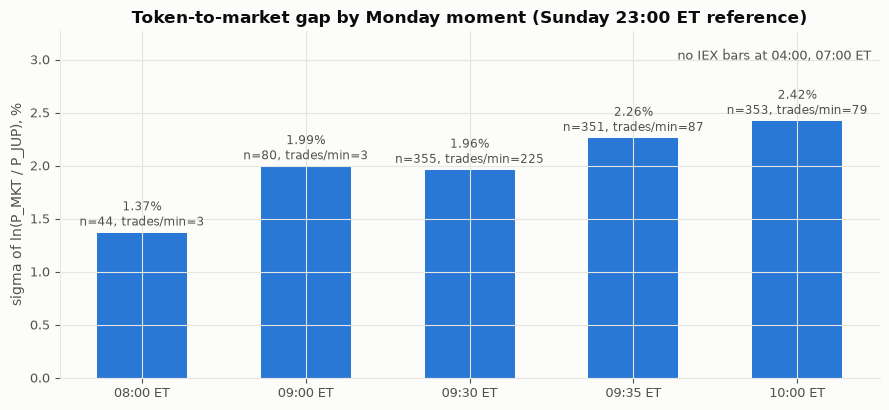

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.2))
sub = mt_sun.dropna(subset=["sigma"])
x = np.arange(len(sub))
ax.bar(x, sub.sigma * 100, color=C["blue"], width=0.55)
for i, (m, r) in enumerate(sub.iterrows()):
    ax.text(i, r.sigma * 100 + 0.03, f"{r.sigma:.2%}\nn={int(r.n_pairs)}, trades/min={r.mean_trade_count:.0f}",
            ha="center", va="bottom", fontsize=8.5, color=C["ink2"])
ax.set_xticks(x, [f"{m} ET" for m in sub.index])
ax.set_ylabel("sigma of ln(P_MKT / P_JUP), %")
ax.set_ylim(0, (sub.sigma.max() * 100) * 1.35)
ax.set_title("Token-to-market gap by Monday moment (Sunday 23:00 ET reference)")
missing = [m for m in MOMENTS if m not in sub.index]
ax.text(0.99, 0.95, f"no IEX bars at {', '.join(missing)} ET", transform=ax.transAxes,
        ha="right", va="top", fontsize=9, color=C["ink2"])
save(fig, "02_sigma_by_moment")

In [14]:
# Choose the settlement moment: the smallest sigma among moments with acceptable liquidity.
MIN_TRADES_PER_MIN = 20   # below this, a one-minute bar is a handful of odd lots, not a price
eligible = mt_sun[(mt_sun.mean_trade_count >= MIN_TRADES_PER_MIN) & mt_sun.sigma.notna()]
CHOSEN = eligible.sigma.idxmin()
print(f"Moments with >= {MIN_TRADES_PER_MIN} trades per minute: {list(eligible.index)}")
print(f"Chosen settlement moment: {CHOSEN} ET  (sigma {eligible.loc[CHOSEN, 'sigma']:.2%}, "
      f"median |gap| {eligible.loc[CHOSEN, 'median_abs_gap']:.2%})")

Moments with >= 20 trades per minute: ['09:30', '09:35', '10:00']
Chosen settlement moment: 09:30 ET  (sigma 1.96%, median |gap| 0.78%)


### Why this moment

Two things decide it. First, liquidity: at 08:00 and 09:00 ET a bar holds about three trades, which is not a price a broker can settle a customer at, and the 08:00 sigma rests on only 44 pairs, the quiet weekends when someone happened to trade early. From 09:30 the auction gives hundreds of trades per minute. Second, among the liquid moments the sigma is smallest at the auction and grows through the next half hour, so waiting past 09:30 adds gap risk and buys nothing.

ADR-017 wanted "premarket, as early as liquid". This dataset cannot see 04:00 to 08:00, so it cannot yet confirm or reject that an earlier premarket moment is liquid enough. The sampler's five-minute record, together with a consolidated feed, is what will answer that.

### Per-token sigma at the chosen moment

In [15]:
gcol = f"gap_sun23_{CHOSEN}"
tok_stats = wk.groupby("token")[gcol].apply(describe_gaps).unstack()
tok_stats["n"] = tok_stats.n.astype(int)
tok_stats["mean_staleness_h"] = wk.groupby("token").stale_sun23.mean()
pooled_sigma_tok = wk[gcol].std(ddof=1)
print(f"Pooled token-gap sigma at {CHOSEN} ET: {pooled_sigma_tok:.2%}  "
      f"(n = {wk[gcol].notna().sum()} token-weekends)")
tok_stats.sort_values("sigma")[["n", "mean", "sigma", "p1", "p99", "excess_kurtosis", "mean_staleness_h"]]

Pooled token-gap sigma at 09:30 ET: 1.96%  (n = 355 token-weekends)


,n,mean,sigma,p1,p99,excess_kurtosis,mean_staleness_h
token,,,,,,,
SPYx,25,-0.0019,0.0056,-0.0104,0.0118,1.1146,0.0400
METAx,8,0.0035,0.0060,-0.0043,0.0116,-1.6413,0.7500
MCDx,8,-0.0120,0.0064,-0.0222,-0.0035,-0.5704,1.1250
GLDx,25,0.0010,0.0068,-0.0107,0.0132,-0.7594,0.0000
QQQx,25,0.0014,0.0076,-0.0117,0.0142,-0.9947,0.0000
AMZNx,25,0.0022,0.0078,-0.0117,0.0239,3.6187,0.2400
GOOGLx,25,0.0010,0.0084,-0.0149,0.0163,-0.4719,0.0000
AAPLx,25,0.0006,0.0087,-0.0200,0.0170,1.4404,0.0400
NVDAx,25,0.0031,0.0104,-0.0188,0.0262,1.3405,0.0000


Tokens with n below 10 have a sigma that is little more than a guess. With 8 weekends, one wild weekend moves sigma by a third. Treat those rows as a first look, not a measurement.

## 3. Tracking in hours

When the share and the token trade at the same time, how far apart are their prices? This is the tracking error. If the token tracks the share well during the day, then the weekend gap measured above is really about the weekend, not about the token being a poor copy of the share.

### Method

For each trading day, take the token's hourly candle that starts at 15:00 ET (its close is the last token trade before 16:00 ET, the share's closing bell) and the share's daily close. Compute ln(token / share). A value of 0 means the two prices agree exactly; 0.01 means the token is 1% above the share.

In [16]:
cand["et"] = cand.bucket_start.dt.tz_convert(ET)
close_candles = cand[(cand.et.dt.hour == 15) & (cand.et.dt.weekday < 5)].copy()
close_candles["date"] = close_candles.et.dt.date
close_candles["share"] = close_candles.symbol.map(SHARE_OF)
track = close_candles.dropna(subset=["share"]).merge(
    daily[["symbol", "date", "close"]].rename(columns={"symbol": "share", "close": "share_close"}),
    on=["share", "date"], how="inner")
track["te"] = np.log(track.close / track.share_close)
te_stats = track.groupby("symbol").te.agg(n="size", mean="mean", sigma="std",
                                          p5=lambda s: s.quantile(0.05), p95=lambda s: s.quantile(0.95))
print(f"Pooled in-hours tracking sigma: {track.te.std():.2%}; pooled median |error|: {track.te.abs().median():.2%}")
te_stats.sort_values("sigma")

Pooled in-hours tracking sigma: 1.42%; pooled median |error|: 0.24%


,n,mean,sigma,p5,p95
symbol,,,,,
NVDAx,125,-0.0000,0.0018,-0.0030,0.0029
TSLAx,125,-0.0003,0.0019,-0.0033,0.0028
QQQx,125,0.0016,0.0022,-0.0016,0.0050
CRCLx,125,-0.0001,0.0024,-0.0040,0.0035
GLDx,125,0.0002,0.0026,-0.0037,0.0046
AMZNx,121,-0.0001,0.0027,-0.0039,0.0040
AAPLx,123,0.0016,0.0029,-0.0027,0.0062
MSTRx,125,0.0010,0.0029,-0.0042,0.0060
MCDx,32,0.0154,0.0033,0.0108,0.0209


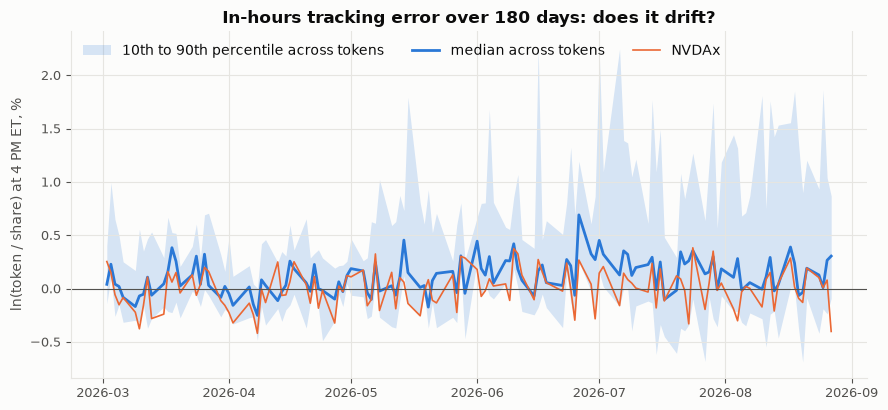

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.2))
daily_med = track.groupby("date").te.median()
daily_p = track.groupby("date").te.quantile([0.1, 0.9]).unstack()
ax.fill_between(pd.to_datetime(daily_p.index), daily_p[0.1] * 100, daily_p[0.9] * 100,
                color=C["blue"], alpha=0.18, lw=0, label="10th to 90th percentile across tokens")
ax.plot(pd.to_datetime(daily_med.index), daily_med * 100, color=C["blue"], lw=2, label="median across tokens")
nv = track[track.symbol == "NVDAx"].set_index("date").te.sort_index()
ax.plot(pd.to_datetime(nv.index), nv * 100, color=C["orange"], lw=1.2, label="NVDAx")
ax.axhline(0, color=C["ink2"], lw=0.8)
ax.set_ylabel("ln(token / share) at 4 PM ET, %"); ax.set_xlabel("")
ax.set_title("In-hours tracking error over 180 days: does it drift?")
ax.legend(loc="upper left", ncol=3)
save(fig, "03_tracking_drift")

If the median line stays near zero and the band does not widen over time, the token is a stable copy of the share. A persistent offset would mean a premium or discount that the ERR formula would need to account for as a bias term.

Two tokens do carry a persistent offset. STRCx trades about 5% above STRC (a preferred share with a $100 par value, so the token's price may include accrued dividend) and MCDx about 1.5% above MCD. For those two, the weekend "gap" measured in section 2 is mostly this premium, and the right fix is a bias term, not a wider sigma. The band widens from June onward because that is when the thin July-only tokens enter the sample, not because the dense tokens drift.

### Today's live sampler

The `token_prices` table began recording at about 17:08 UTC today. It holds only a few hours, all inside market hours. The figure below is the in-hours gap for every token in that window. This table grows by one row per token every five minutes from now on, including all weekend, and it is the future of this analysis: it will show the token price at 04:00 ET beside the first real premarket trade, which the backfilled data cannot.

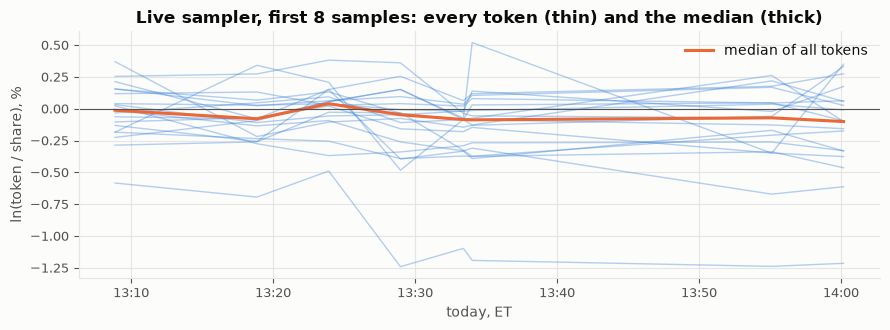

live in-hours samples: 152 rows, median |gap| 0.14%, widest 1.24% (PLTRx)


In [18]:
live = q("""select sampled_at, symbol, usd_price, market_price, market_open
            from token_prices where underlying is not null order by sampled_at""")
live["gap"] = np.log(live.usd_price.astype(float) / live.market_price.astype(float))
live_in = live[live.market_open]
fig, ax = plt.subplots(figsize=(9, 3.4))
for sym, g in live_in.groupby("symbol"):
    ax.plot(g.sampled_at.dt.tz_convert(ET), g.gap * 100, color=C["blue"], alpha=0.35, lw=1)
med = live_in.groupby("sampled_at").gap.median()
ax.plot(med.index.tz_convert(ET), med * 100, color=C["orange"], lw=2.2, label="median of all tokens")
ax.axhline(0, color=C["ink2"], lw=0.8)
ax.set_ylabel("ln(token / share), %"); ax.set_xlabel("today, ET")
ax.set_title(f"Live sampler, first {len(med)} samples: every token (thin) and the median (thick)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M", tz=ET))
save(fig, "03b_live_sampler_today")
print(f"live in-hours samples: {len(live_in)} rows, median |gap| {live_in.gap.abs().median():.2%}, "
      f"widest {live_in.gap.abs().max():.2%} ({live_in.loc[live_in.gap.abs().idxmax(), 'symbol']})")

## 4. ERR back-test

A **back-test** replays the past as if the system had been running: for each weekend, size the reserve with only the information that was available before that weekend, then check whether the actual gap breached it.

**No look-ahead.** The sigma used for a weekend is estimated only from the weekends *before* it (an **expanding window**, with at least 8 prior observations). If we estimated sigma from all weekends including the one being tested, the reserve would "know" about the gap it is supposed to protect against, and the breach rate would look better than any live system could achieve.

The formula is the paper's, with Q = 1, P_open = P_JUP, and fees ignored:

$$\text{ERR}_{\text{initial}} = P_{\text{JUP}} \cdot \sigma_{\text{gap}} \cdot z$$

Two multipliers are tested:

- **(a) z = 2.326**, the one-sided 99% point of the bell curve.
- **(b) empirical z**: the 99th percentile of the prior |gaps|, divided by the prior sigma. This lets the fat tails set the multiplier.

Each weekend is scored twice: once as a **sell** (breach if the market opens below the token price by more than the reserve) and once as a **buy** (breach if it opens above). The target is a 1% breach rate on each side. **Capital drag** is the reserve as a percent of notional, averaged over all trades: what a trader's cash is tied up for.

Two ways to estimate sigma are compared. **Per-token**: only that token's prior weekends. **Pooled**: all tokens' prior weekends together, which gives thin tokens a usable estimate at the cost of ignoring differences between tickers.

In [19]:
MIN_PRIOR = 8
g_all = wk[["token", "monday", "p_sun23", gcol]].dropna().sort_values(["monday", "token"]).reset_index(drop=True)
g_all = g_all.rename(columns={gcol: "gap"})

def backtest(pooled: bool) -> pd.DataFrame:
    out = []
    for i, row in g_all.iterrows():
        prior = g_all[g_all.monday < row.monday] if pooled else \
                g_all[(g_all.monday < row.monday) & (g_all.token == row.token)]
        if len(prior) < MIN_PRIOR:
            continue
        sigma = prior.gap.std(ddof=1)
        z_emp = np.quantile(prior.gap.abs(), 0.99) / sigma
        for name, zz in (("normal z=2.326", Z_NORMAL), ("empirical z", z_emp)):
            reserve = sigma * zz                       # as a fraction of notional
            out.append(dict(token=row.token, monday=row.monday, multiplier=name, z=zz,
                            sigma=sigma, reserve_frac=reserve,
                            sell_breach=(-row.gap) > reserve, buy_breach=row.gap > reserve))
    return pd.DataFrame(out)

def summarise(bt: pd.DataFrame) -> pd.DataFrame:
    return bt.groupby("multiplier").agg(
        trades=("token", "size"), mean_z=("z", "mean"),
        sell_breach_rate=("sell_breach", "mean"), buy_breach_rate=("buy_breach", "mean"),
        capital_drag=("reserve_frac", "mean"))

bt_tok, bt_pool = backtest(False), backtest(True)
print("Per-token sigma (needs 8 prior weekends of the same token):")
display(summarise(bt_tok))
print("Pooled sigma (8 prior token-weekends from any token):")
display(summarise(bt_pool))

Per-token sigma (needs 8 prior weekends of the same token):


,trades,mean_z,sell_breach_rate,buy_breach_rate,capital_drag
multiplier,,,,,
empirical z,204,2.2648,0.0539,0.0098,0.0332
normal z=2.326,204,2.3263,0.0539,0.0098,0.0322


Pooled sigma (8 prior token-weekends from any token):


,trades,mean_z,sell_breach_rate,buy_breach_rate,capital_drag
multiplier,,,,,
empirical z,344,3.6678,0.0087,0.0116,0.0690
normal z=2.326,344,2.3263,0.0465,0.0233,0.0438


Read `sell_breach_rate` and `buy_breach_rate` against the 1% target. A rate near 1% means the reserve did its job. `capital_drag` is the price of that safety: the share of the trade's value that sat in escrow.

The per-token empirical z looks broken, and the reason matters. With 8 to 17 prior weekends, the 99th percentile of |gap| is just the largest gap seen so far, so the multiplier collapses to about 2.3 and cannot see a tail that has not happened yet. That is why pooling across tokens, or borrowing the multiplier from the two-year market sample, is the only honest option until each token has years of history.

**The sample-size caveat, plainly.** Each token has about 25 weekends at most; after the 8-weekend warm-up, the per-token back-test scores about 17 weekends per dense token and few or none for tokens with a short history. With 17 weekends, a 1% breach rate means "zero or one breach", so the per-token rates are very rough. Pooling gives a few hundred trades, which is enough to tell 1% from 3%. Both tables should be re-run every few weeks as the sampler adds weekends.

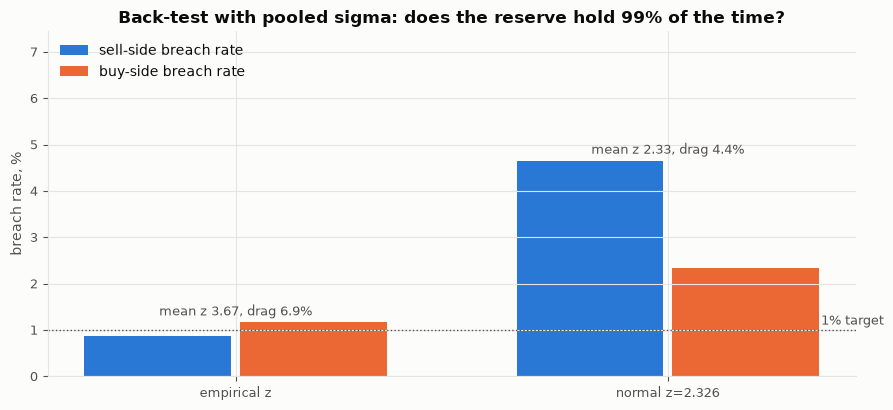

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.2))
s = summarise(bt_pool)
x = np.arange(len(s))
ax.bar(x - 0.18, s.sell_breach_rate * 100, width=0.34, color=C["blue"], label="sell-side breach rate")
ax.bar(x + 0.18, s.buy_breach_rate * 100, width=0.34, color=C["orange"], label="buy-side breach rate")
ax.axhline(1.0, color=C["ink2"], lw=1, ls=":")
ax.text(len(s) - 0.5, 1.05, "1% target", ha="right", va="bottom", fontsize=9, color=C["ink2"])
for i, (name, r) in enumerate(s.iterrows()):
    ax.text(i, max(r.sell_breach_rate, r.buy_breach_rate) * 100 + 0.15,
            f"mean z {r.mean_z:.2f}, drag {r.capital_drag:.1%}", ha="center", fontsize=9, color=C["ink2"])
ax.set_xticks(x, s.index); ax.set_ylabel("breach rate, %")
ax.set_title("Back-test with pooled sigma: does the reserve hold 99% of the time?")
ax.set_ylim(0, max(1.5, (s[["sell_breach_rate", "buy_breach_rate"]].max().max() * 100) * 1.6))
ax.legend(loc="upper left")
save(fig, "04_backtest_breach_rates")

## 5. Conclusions

### One table

Per ticker: the two-year market-gap sigma (Friday close to next open, real share), the 180-day token-gap sigma at the chosen settlement moment (Sunday 23:00 ET token price to the Monday bar), and the 99th-percentile multiplier from the two-year market gaps (the z that would have given a true 1% one-sided breach).

In [21]:
def z99(s: pd.Series) -> float:
    """99th percentile of |gap| divided by sigma: the empirical replacement for 2.326."""
    return np.quantile(s.abs(), 0.99) / s.std(ddof=1)

summary = pd.DataFrame({
    "sigma_market_gap_2y": mkt_stats.sigma,
    "n_weekends_2y": mkt_stats.n,
    "z99_market_2y": mkt_gap.groupby("symbol").r.apply(z99),
})
summary.index.name = "share"
tok_side = tok_stats[["sigma", "n"]].rename(columns={"sigma": f"sigma_token_gap_{CHOSEN}", "n": "n_weekends_token"})
tok_side.index = [SHARE_OF[t] for t in tok_side.index]
summary = summary.join(tok_side)
summary.loc["POOLED"] = [pooled_sigma_mkt, len(mkt_gap), z99(mkt_gap.r), pooled_sigma_tok, wk[gcol].notna().sum()]
summary = summary.sort_values("sigma_market_gap_2y")
summary

,sigma_market_gap_2y,n_weekends_2y,z99_market_2y,sigma_token_gap_09:30,n_weekends_token
share,,,,,
MCD,0.0071,103.0000,3.1277,0.0064,8.0000
SPY,0.0090,103.0000,3.7385,0.0056,25.0000
MSFT,0.0112,103.0000,4.0519,0.0174,25.0000
QQQ,0.0119,103.0000,3.2146,0.0076,25.0000
STRC,0.0126,53.0000,4.1358,0.0227,15.0000
GLD,0.0128,103.0000,2.5924,0.0068,25.0000
GOOGL,0.0152,103.0000,2.5868,0.0084,25.0000
META,0.0161,103.0000,3.8730,0.0060,8.0000
AAPL,0.0170,103.0000,3.8054,0.0087,25.0000


In [22]:
# The paper's running example: 10 NVDA at $226, with measured numbers instead of placeholders.
Q, P = 10, 226.0
s_mkt = summary.loc["NVDA", "sigma_market_gap_2y"]
s_tok = summary.loc["NVDA", f"sigma_token_gap_{CHOSEN}"]
z_emp_nvda = summary.loc["NVDA", "z99_market_2y"]
z_emp_pool = summary.loc["POOLED", "z99_market_2y"]
print(f"Paper's placeholder:  10 x $226 x 2.0% x 2.326 = ${Q*P*0.02*Z_NORMAL:,.2f}")
print(f"Market gap, z=2.326:  10 x $226 x {s_mkt:.2%} x 2.326 = ${Q*P*s_mkt*Z_NORMAL:,.2f}")
print(f"Market gap, z={z_emp_nvda:.2f}:   10 x $226 x {s_mkt:.2%} x {z_emp_nvda:.2f} = ${Q*P*s_mkt*z_emp_nvda:,.2f}")
print(f"Token gap,  z=2.326:  10 x $226 x {s_tok:.2%} x 2.326 = ${Q*P*s_tok*Z_NORMAL:,.2f}")
print(f"Token gap,  z={z_emp_pool:.2f}:   10 x $226 x {s_tok:.2%} x {z_emp_pool:.2f} = ${Q*P*s_tok*z_emp_pool:,.2f}  (pooled z99)")
print(f"\nnotebook runtime: {time.time() - T0:.0f} s")

Paper's placeholder:  10 x $226 x 2.0% x 2.326 = $105.15
Market gap, z=2.326:  10 x $226 x 2.70% x 2.326 = $142.07
Market gap, z=4.89:   10 x $226 x 2.70% x 4.89 = $298.74
Token gap,  z=2.326:  10 x $226 x 1.04% x 2.326 = $54.63
Token gap,  z=3.78:   10 x $226 x 1.04% x 3.78 = $88.67  (pooled z99)

notebook runtime: 11 s


### In plain words

**The settlement moment is the 09:30 ET opening auction.** Among the moments this dataset can see with real liquidity (about 225 trades per minute at 09:30, under 100 after it), the auction has the smallest gap from the Sunday-night token price: sigma 1.96%, median |gap| 0.78%. The gap grows through the first half hour of trading, so waiting past the auction costs money and buys nothing. The 08:00 bar looks smaller (1.37%) but rests on 44 pairs with three trades per bar; it is a selection of quiet weekends, not a better price. ADR-017's hope of an earlier premarket fill is not rejected. It is untested, because the free IEX feed prints nothing before 08:00. The live sampler, which began today and records the token price every five minutes including the 04:00 ET moment, is the tool that will test it.

**z = 2.326 is not honest.** Over two years and 1,864 real weekend gaps, the bell-curve multiplier is breached 1.93% of the time on the sell side and 1.50% on the buy side, about double its promise. The pooled excess kurtosis is 27; the tails are very fat. In the token back-test with no look-ahead, z = 2.326 on a pooled sigma was breached 4.65% (sell) and 2.33% (buy) of the time. The empirical multiplier, about 3.7 from the prior weekends, brought both sides to about 1% (0.87% sell, 1.16% buy) at a capital drag of 6.9% of notional instead of 4.4%. A per-token empirical multiplier does not work yet: with 8 to 17 prior weekends the 99th percentile is just the largest gap seen so far, so the multiplier collapses to about 2.3 and the sell-side breach rate is 5.4%. Until each token has a few years of weekends, the multiplier must come from the pooled or the two-year market sample. The recommendation is **z between 3.5 and 4**, or better, the empirical 99th percentile itself.

**What this means for 10 NVDA at $226.** The paper's placeholder gives $105. NVDA's measured token gap at the auction is sigma 1.04% (25 weekends), which with z = 2.326 gives $55 and with the pooled empirical z of 3.78 gives $89. NVDA's own two-year market gap is wider, sigma 2.70%, because it contains earnings weekends and the 2025 tariff shock; with its own 99th-percentile multiplier of 4.89 the reserve is $299. The honest range for this trade today is **$90 to $300**, and the paper's $105 sits at the low end of it. A reserve of about $150 (6.6% of notional) covers 99% of the weekends in both samples.

**What the data cannot say yet.** Twenty-five weekends per token is thin: one earnings weekend changes a token's sigma by a third, and seven tokens have only eight weekends. The token sample (March to August 2026) contains no crash. Two tokens, STRCx and MCDx, trade at a persistent premium to their share (about +5% and +1.5% in hours), so their "gap" is mostly that premium and needs a bias term, not a bigger sigma. In-hours tracking for the dense tokens is tight (NVDAx sigma 0.18%, median |error| 0.24% across all tokens), so the weekend gap is a weekend effect, not a broken peg. This weekend's sampler data adds the first direct observation of the token at 04:00 ET beside the first premarket trade; every weekend after it adds one more row to every table above. Re-run this notebook after each one.